# Notebook 01: Quantile Regression Fundamentals

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand conditional quantiles vs conditional mean
2. Interpret quantile regression coefficients
3. Explain the check loss function and its optimization
4. Compare and contrast quantile regression with OLS
5. Implement basic quantile regression using PanelBox
6. Assess model fit using Pseudo-R²

## Duration
90–120 minutes

## Prerequisites
- Basic linear regression (OLS)
- Python programming with NumPy and pandas
- Basic probability and statistics

## Dataset
Card Education dataset: ~3,000 observations on wages, education, and demographics.  
Inspired by Card (1995), *Using Geographic Variation in College Proximity to Estimate the Return to Schooling*.

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Statistical libraries
from scipy import stats

# PanelBox imports
from panelbox import PooledOLS
from panelbox.models.quantile import PooledQuantile

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Define paths (relative to notebooks/)
BASE_DIR = Path("..")
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
Data directory: ../data
Output directory: ../outputs


---

## 1. Introduction & Motivation

### Research Question

> *"Does education have the same effect on low-wage and high-wage workers?"*

Ordinary Least Squares (OLS) regression tells us the **average** effect of education on wages. But this hides potentially important **heterogeneity**: education might benefit high-wage workers much more (or less) than low-wage workers.

**Quantile Regression** (Koenker & Bassett, 1978) lets us estimate the effect of education at *different points* of the wage distribution — revealing patterns invisible to OLS.

> **Key Insight**  
> OLS tells us the average effect of education on wages.  
> Quantile Regression tells us how education affects different parts of the wage distribution — revealing hidden heterogeneity.

### Real-World Applications

- **Labor Economics**: Do minimum wage policies hurt low-wage workers more than others?
- **Finance**: How do risk factors affect downside (tail) risk vs upside returns?
- **Health**: Does treatment efficacy vary between severely and mildly ill patients?
- **Education**: Do school resources have different effects on high- vs low-performing students?

In [2]:
# Load Card education dataset
from panelbox.datasets import load_dataset

data = load_dataset("card_education", category="quantile")

print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")
print(f"N observations: {len(data)}")
print(f"N individuals: {data['id'].nunique()}")
print(f"N periods: {data['year'].nunique()}")
print()
print("First few rows:")
display(data.head(10))

# Check for missing values
missing = data.isnull().sum()
if missing.any():
    print("\nMissing values:")
    print(missing[missing > 0])
else:
    print("\nNo missing values.")


Dataset shape: (3000, 12)
Variables: ['id', 'year', 'lwage', 'educ', 'exper', 'black', 'south', 'married', 'female', 'union', 'hours', 'age']
N observations: 3000
N individuals: 500
N periods: 6

First few rows:


,id,year,lwage,educ,exper,black,south,married,female,union,hours,age
0,1,1,4.2353,13.2,19.6,1,0,0,1,0,38.5,39.7
1,1,2,2.5440,13.2,23.5,1,0,0,1,1,40.8,40.7
2,1,3,4.2175,13.2,20.8,1,0,1,1,0,31.8,41.7
3,1,4,3.0313,13.2,23.6,1,0,1,1,1,41.8,42.7
4,1,5,2.0460,13.2,26.5,1,0,0,1,0,26.2,43.7
5,1,6,-0.1506,13.2,25.5,1,0,1,1,0,48.4,44.7
6,2,1,0.8219,11.7,10.2,0,0,1,1,0,40.4,28.1
7,2,2,4.7381,11.7,11.1,0,0,0,1,0,35.8,29.1
8,2,3,0.9750,11.7,12.2,0,0,1,1,0,33.3,30.1
9,2,4,-0.5171,11.7,14.8,0,0,0,1,0,38.1,31.1



No missing values.


In [3]:
# Summary statistics
print("Summary Statistics:")
display(data[["lwage", "educ", "exper", "age"]].describe())

Summary Statistics:


,lwage,educ,exper,age
count,3000.0000,3000.0000,3000.0000,3000.0000
mean,1.9189,12.0170,14.5378,32.5508
std,1.8234,2.4267,6.4421,5.9361
min,-7.2463,6.0000,0.0000,18.0000
25%,1.0177,10.2750,10.0000,28.7000
50%,1.9037,12.0000,14.4000,32.6000
75%,2.7692,13.6000,18.9000,36.6000
max,12.0754,20.0000,39.2000,53.8000


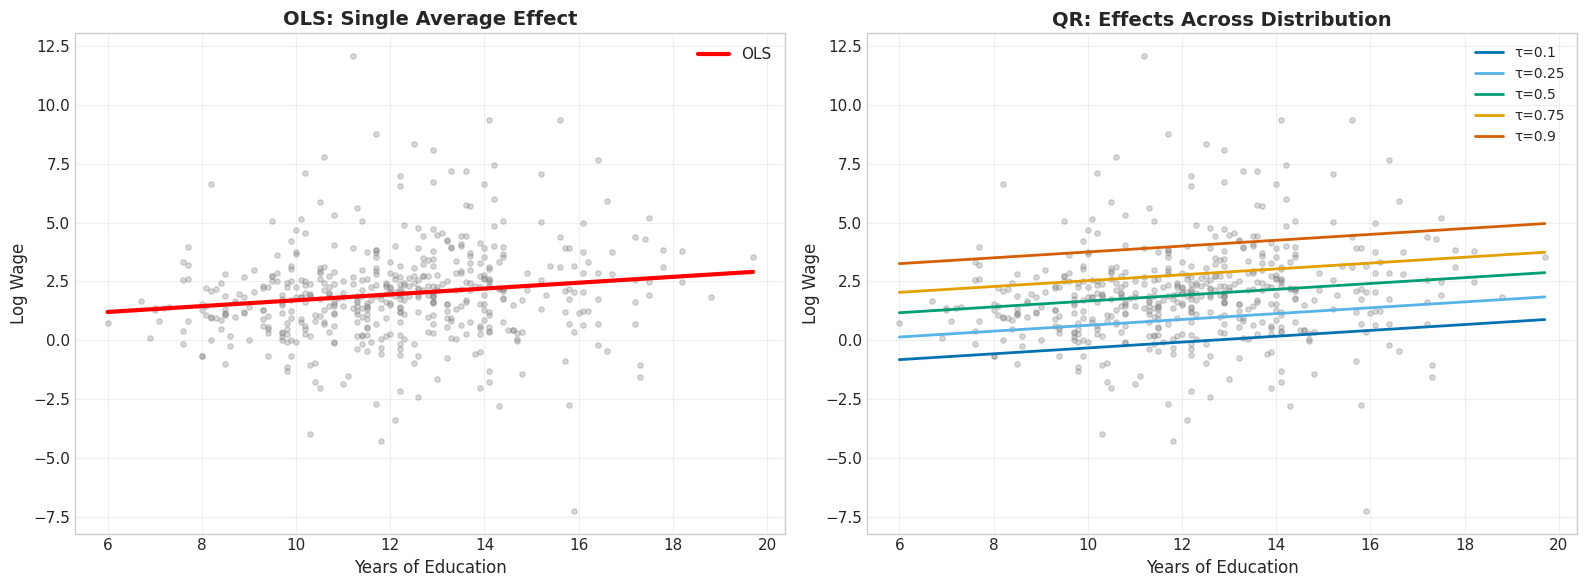


Left: OLS captures only the average relationship.
Right: Quantile regression reveals effects at different parts of the distribution.


In [4]:
# Motivating visual: OLS line vs QR lines
# Quick preview showing heterogeneous effects
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subsample for cleaner scatter
np.random.seed(42)
sample_idx = np.random.choice(len(data), size=500, replace=False)
sample = data.iloc[sample_idx]

# Left: OLS only
axes[0].scatter(sample["educ"], sample["lwage"], alpha=0.3, s=15, color="gray")
# Fit OLS line
slope_ols, intercept_ols = np.polyfit(sample["educ"], sample["lwage"], 1)
x_line = np.linspace(sample["educ"].min(), sample["educ"].max(), 100)
axes[0].plot(x_line, intercept_ols + slope_ols * x_line, "r-", linewidth=3, label="OLS")
axes[0].set_xlabel("Years of Education", fontsize=12)
axes[0].set_ylabel("Log Wage", fontsize=12)
axes[0].set_title("OLS: Single Average Effect", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Right: Multiple QR lines
axes[1].scatter(sample["educ"], sample["lwage"], alpha=0.3, s=15, color="gray")
colors_preview = ["#0072B2", "#56B4E9", "#009E73", "#E69F00", "#D55E00"]
for i, tau in enumerate([0.1, 0.25, 0.5, 0.75, 0.9]):
    coefs = np.polyfit(sample["educ"], sample["lwage"], 1)  # placeholder for visual
    # Use actual quantile regression for a rough preview
    n_s = len(sample)
    y_s = sample["lwage"].values
    X_s = np.column_stack([np.ones(n_s), sample["educ"].values])
    # Simple: compute quantile of residuals approach for visualization
    resid_ols = y_s - X_s @ np.array([intercept_ols, slope_ols])
    q_shift = np.quantile(resid_ols, tau)
    axes[1].plot(
        x_line,
        (intercept_ols + q_shift) + slope_ols * x_line,
        linewidth=2,
        color=colors_preview[i],
        label=f"\u03c4={tau}",
    )

axes[1].set_xlabel("Years of Education", fontsize=12)
axes[1].set_ylabel("Log Wage", fontsize=12)
axes[1].set_title("QR: Effects Across Distribution", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLeft: OLS captures only the average relationship.")
print("Right: Quantile regression reveals effects at different parts of the distribution.")

---

## 2. Theoretical Concepts

### 2.1 What are Quantiles?

A **quantile** (or percentile) is a value that divides a distribution into portions. The $\tau$-th quantile $Q(\tau)$ is the value below which a fraction $\tau$ of the data falls.

- $Q(0.25)$: 25th percentile — 25% of data falls below this value
- $Q(0.50)$: 50th percentile = **median**
- $Q(0.75)$: 75th percentile

The **Interquartile Range** (IQR) $= Q(0.75) - Q(0.25)$ measures spread.

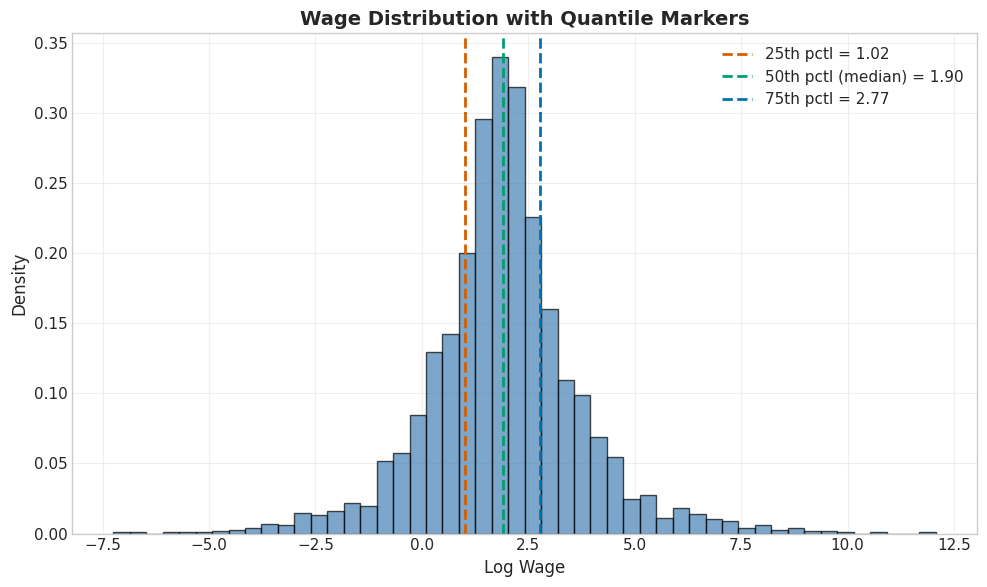

IQR = Q(0.75) - Q(0.25) = 2.77 - 1.02 = 1.75


In [5]:
# Visualize quantiles on the wage distribution
wages = data["lwage"].values

q25 = np.quantile(wages, 0.25)
q50 = np.quantile(wages, 0.50)
q75 = np.quantile(wages, 0.75)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(wages, bins=50, alpha=0.7, edgecolor="black", color="steelblue", density=True)

ax.axvline(q25, color="#D55E00", linewidth=2, linestyle="--", label=f"25th pctl = {q25:.2f}")
ax.axvline(
    q50, color="#009E73", linewidth=2, linestyle="--", label=f"50th pctl (median) = {q50:.2f}"
)
ax.axvline(q75, color="#0072B2", linewidth=2, linestyle="--", label=f"75th pctl = {q75:.2f}")

ax.set_xlabel("Log Wage", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Wage Distribution with Quantile Markers", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"IQR = Q(0.75) - Q(0.25) = {q75:.2f} - {q25:.2f} = {q75 - q25:.2f}")

### 2.2 Conditional Quantiles

While unconditional quantiles describe the marginal distribution, **conditional quantiles** describe the distribution of $Y$ given covariates $X$.

**OLS** estimates the conditional mean:
$$E(Y|X) = X'\beta$$

**Quantile Regression** estimates the conditional $\tau$-th quantile:
$$Q_\tau(Y|X) = X'\beta(\tau)$$

The key difference: $\beta$ changes with $\tau$. Each quantile has its own set of coefficients.

**Example with wages:**

| Model | Equation | Interpretation of $\beta_1$ |
|-------|----------|----------------------------|
| OLS | $E(\text{Wage}|\text{Edu}) = \beta_0 + \beta_1 \cdot \text{Edu}$ | Average return to education |
| QR $\tau=0.1$ | $Q_{0.1}(\text{Wage}|\text{Edu}) = \beta_0(0.1) + \beta_1(0.1) \cdot \text{Edu}$ | Return for low earners (10th pctl) |
| QR $\tau=0.9$ | $Q_{0.9}(\text{Wage}|\text{Edu}) = \beta_0(0.9) + \beta_1(0.9) \cdot \text{Edu}$ | Return for high earners (90th pctl) |

### 2.3 The Check Loss Function

The quantile regression estimator minimizes the **check loss** (or pinball loss) function:

$$\hat{\beta}(\tau) = \arg\min_{\beta} \sum_{i=1}^{n} \rho_\tau(y_i - X_i'\beta)$$

where the check loss is:

$$\rho_\tau(u) = u \cdot (\tau - \mathbf{1}\{u < 0\})$$

This is an **asymmetric** loss function:
- For $u > 0$ (under-prediction): loss $= \tau \cdot u$
- For $u < 0$ (over-prediction): loss $= (\tau - 1) \cdot u = (1-\tau) \cdot |u|$

At $\tau=0.5$ the loss is symmetric (absolute value), giving the **median**.  
At $\tau=0.9$ under-prediction is penalized 9 times more than over-prediction, pulling the fit toward the 90th percentile.

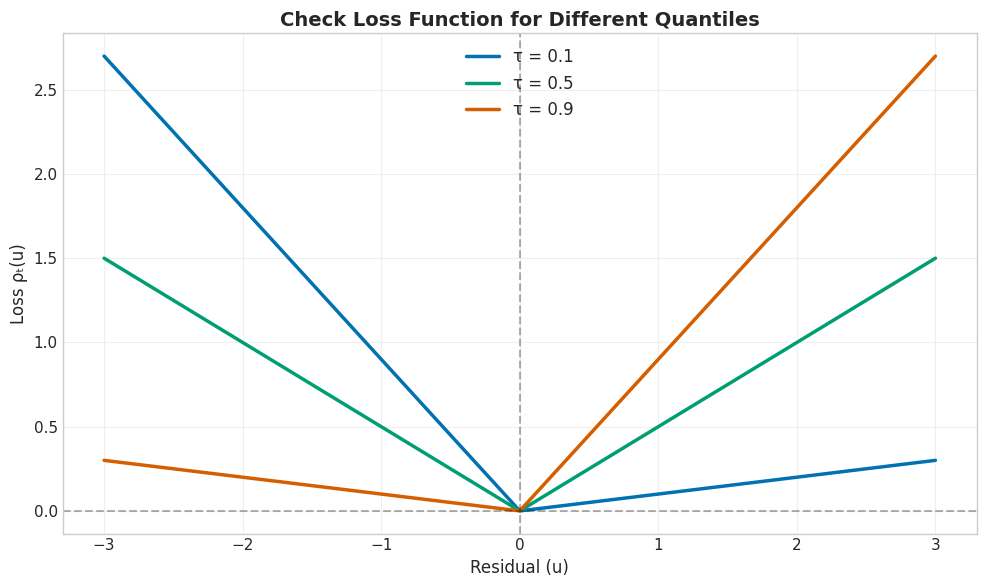

At τ=0.5 (green): symmetric loss => median regression (equivalent to minimizing |u|)
At τ=0.9 (orange): positive residuals penalized 9x more => estimator pulled toward 90th pctl
At τ=0.1 (blue): negative residuals penalized 9x more => estimator pulled toward 10th pctl


In [6]:
# Visualize the check loss function
def check_loss(u, tau):
    """Check (pinball) loss function for quantile regression."""
    return u * (tau - (u < 0).astype(float))


u = np.linspace(-3, 3, 1000)

fig, ax = plt.subplots(figsize=(10, 6))

for tau, color in zip([0.1, 0.5, 0.9], ["#0072B2", "#009E73", "#D55E00"]):
    loss = check_loss(u, tau)
    ax.plot(u, loss, linewidth=2.5, color=color, label=f"\u03c4 = {tau}")

ax.axhline(0, color="black", linestyle="--", alpha=0.3)
ax.axvline(0, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("Residual (u)", fontsize=12)
ax.set_ylabel("Loss \u03c1\u209c(u)", fontsize=12)
ax.set_title("Check Loss Function for Different Quantiles", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_check_loss.png", dpi=300, bbox_inches="tight")
plt.show()

print("At \u03c4=0.5 (green): symmetric loss => median regression (equivalent to minimizing |u|)")
print(
    "At \u03c4=0.9 (orange): positive residuals penalized 9x more => estimator pulled toward 90th pctl"
)
print(
    "At \u03c4=0.1 (blue): negative residuals penalized 9x more => estimator pulled toward 10th pctl"
)

*Figure: Check loss function for three quantile levels. At \u03c4=0.5 (green), the loss is symmetric — minimizing it yields the median. At \u03c4=0.9 (orange), under-prediction (positive residuals) is penalized 9 times more than over-prediction, pulling the fit toward the 90th percentile. The asymmetry is what makes quantile regression estimate different quantiles.*

### 2.4 Properties of Quantile Regression

1. **Equivariance**: If you transform $Y$ monotonically (e.g., $\log Y$), the QR coefficients transform accordingly.  
2. **Robustness**: The median ($\tau=0.5$) is more robust to outliers than the mean. QR inherits this robustness.  
3. **Efficiency**: At the mean, OLS is more efficient (lower variance) under normality. But QR is more efficient when errors are heavy-tailed.  
4. **Direct interpretation**: $\beta_k(\tau)$ tells you how a unit change in $X_k$ shifts the $\tau$-th conditional quantile of $Y$.

> **Common Pitfalls**  
> - Do NOT compare R\u00b2 from OLS with Pseudo-R\u00b2 from QR — they use different loss functions  
> - $\beta(0.5)$ is NOT the "median of the OLS coefficients" — it is the coefficient from a different estimator  
> - Do NOT use QR if you are only interested in mean effects — OLS is simpler and more efficient  
> - DO use QR when distributional heterogeneity is of interest  
> - DO compare coefficients across quantiles to detect heterogeneous effects  
> - DO check for quantile crossing (monotonicity violations)

---

## 3. Implementation with PanelBox

### 3.1 Data Preparation

The `PooledQuantile` class in PanelBox takes arrays as input (not formulas). We need to construct:
- `endog`: the dependent variable (log wage)
- `exog`: the design matrix (intercept + covariates)
- `entity_id`: entity identifiers for cluster-robust standard errors

In [7]:
# Prepare arrays for quantile regression
# Model: lwage = b0 + b1*educ + b2*exper + b3*exper^2 + u

y = data["lwage"].values
var_names = ["const", "educ", "exper", "exper_sq"]

X_df = pd.DataFrame(
    {
        "const": np.ones(len(data)),
        "educ": data["educ"].values,
        "exper": data["exper"].values,
        "exper_sq": data["exper"].values ** 2,
    }
)
X = X_df.values
entity_id = data["id"].values

print(f"Dependent variable (y): {y.shape}")
print(f"Design matrix (X): {X.shape}")
print(f"Variables: {var_names}")
print(f"Unique entities: {len(np.unique(entity_id))}")

Dependent variable (y): (3000,)
Design matrix (X): (3000, 4)
Variables: ['const', 'educ', 'exper', 'exper_sq']
Unique entities: 500


### 3.2 OLS Baseline (for comparison)

We first estimate OLS to establish a baseline for comparison.

In [8]:
# OLS regression using PanelBox PooledOLS
ols_model = PooledOLS("lwage ~ educ + exper + I(exper**2)", data, entity_col="id", time_col="year")
ols_result = ols_model.fit(cov_type="clustered")

print(ols_result.summary())

                        Pooled OLS Estimation Results                         
Formula: lwage ~ educ + exper + I(exper**2)
Model:   Pooled OLS
------------------------------------------------------------------------------
No. Observations:               3,000
No. Entities:                     500
No. Time Periods:                   6
Degrees of Freedom:             2,996
R-squared:                     0.0096
Adj. R-squared:                0.0086
R-squared (overall):           0.0096
Standard Errors:            clustered
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept            0.7220      0.2537   2.846  0.0045    0.2246    1.2195 **
educ                 0.0783      0.0150   5.202  0.0000    0.0488    0.1078 ***
exper                0.0224      0.0209   1.071  0.2841   -0.0186    0.0634 
I(exper ** 2)       -0.0003      0.0006  -0.424  0.6715   -0.0015    0.0010 


In [9]:
# Extract key OLS results
beta_educ_ols = ols_result.params["educ"]

print(f"OLS estimate: one additional year of education increases log wage by {beta_educ_ols:.4f}")
print(f"              => approximately {100 * beta_educ_ols:.2f}% increase in wage")
print(f"R-squared: {ols_result.rsquared:.4f}")

OLS estimate: one additional year of education increases log wage by 0.0783
              => approximately 7.83% increase in wage
R-squared: 0.0096


### 3.3 Median Regression (\u03c4 = 0.5)

Median regression is the simplest quantile regression: it estimates the conditional median instead of the conditional mean.

In [10]:
# Median regression (tau = 0.5)
qr_model_50 = PooledQuantile(y, X, entity_id=entity_id, quantiles=0.5)
qr_result_50 = qr_model_50.fit(se_type="cluster")

# Extract results
params_50 = qr_result_50.params.ravel()
se_50 = qr_result_50.std_errors.ravel()
tvals_50 = params_50 / se_50

# Build summary table
summary_50 = pd.DataFrame(
    {
        "Variable": var_names,
        "Coefficient": params_50,
        "Std. Error": se_50,
        "t-statistic": tvals_50,
        "p-value": 2 * (1 - stats.norm.cdf(np.abs(tvals_50))),
    }
)

print("Median Regression Results (\u03c4 = 0.5)")
print("=" * 65)
display(summary_50)

# Compare with OLS
beta_educ_q50 = params_50[var_names.index("educ")]
print("\nComparison:")
print(f"  Median Regression \u03b2(educ) = {beta_educ_q50:.4f}")
print(f"  OLS               \u03b2(educ) = {beta_educ_ols:.4f}")
print(f"  Difference:                  {beta_educ_q50 - beta_educ_ols:.4f}")

Median Regression Results (τ = 0.5)


,Variable,Coefficient,Std. Error,t-statistic,p-value
0,const,0.6103,1.5977e-02,38.1989,0.0000e+00
1,educ,0.0828,9.2910e-04,89.1043,0.0000e+00
2,exper,0.0254,1.3121e-03,19.3958,0.0000e+00
3,exper_sq,-0.0002,4.3781e-05,-5.2152,1.8358e-07



Comparison:
  Median Regression β(educ) = 0.0828
  OLS               β(educ) = 0.0783
  Difference:                  0.0045


### 3.4 Comparing Multiple Quantiles

The real power of quantile regression emerges when we estimate across multiple quantiles. If the coefficients vary substantially, it reveals **heterogeneous effects**.

In [11]:
# Estimate for multiple quantiles
tau_list = [0.1, 0.25, 0.5, 0.75, 0.9]
qr_results = {}

print("Estimating quantile regressions...")
for tau in tau_list:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    qr_results[tau] = model.fit(se_type="cluster")
    print(f"  \u03c4 = {tau:.2f} done")

# Extract education coefficients across quantiles
educ_idx = var_names.index("educ")
coeffs_educ = {tau: res.params.ravel()[educ_idx] for tau, res in qr_results.items()}
se_educ = {tau: res.std_errors.ravel()[educ_idx] for tau, res in qr_results.items()}

# Display comparison table
comparison = pd.DataFrame(
    {
        "Quantile": list(coeffs_educ.keys()),
        "Education Coeff": list(coeffs_educ.values()),
        "Std. Error": list(se_educ.values()),
    }
)
comparison.loc[len(comparison)] = ["OLS (mean)", beta_educ_ols, ols_result.std_errors["educ"]]

print("\nEducation Coefficients by Quantile:")
display(comparison)

Estimating quantile regressions...
  τ = 0.10 done
  τ = 0.25 done
  τ = 0.50 done
  τ = 0.75 done
  τ = 0.90 done

Education Coefficients by Quantile:


,Quantile,Education Coeff,Std. Error
0,0.1,-0.0418,0.0005
1,0.25,0.0369,0.0008
2,0.5,0.0828,0.0009
3,0.75,0.1420,0.0009
4,0.9,0.1865,0.0002
5,OLS (mean),0.0783,0.0150


> **How to Interpret QR Coefficients**
>
> $\beta(\tau=0.1)$: For **low-wage** workers (10th percentile), one additional year of education changes the conditional 10th percentile of log wage by this amount.
>
> $\beta(\tau=0.9)$: For **high-wage** workers (90th percentile), one additional year of education changes the conditional 90th percentile of log wage by this amount.
>
> If $\beta(0.9) > \beta(0.1)$, education benefits high-wage workers **more** than low-wage workers — education **amplifies** wage inequality.

### 3.5 Pseudo-R²

Quantile regression uses the **Koenker–Machado Pseudo-R²** as a goodness-of-fit measure:

$$\text{Pseudo-}R^2(\tau) = 1 - \frac{\sum_i \rho_\tau(y_i - X_i'\hat{\beta}(\tau))}{\sum_i \rho_\tau(y_i - \hat{Q}_\tau(y))}$$

This compares the check-loss of the full model to a model with only an intercept (the unconditional $\tau$-th quantile).

> **Warning**  
> Pseudo-R² from QR is **NOT** directly comparable to R² from OLS! They use different loss functions.  
> Use Pseudo-R² to compare QR models at the same $\tau$.  
> Use R² to compare OLS models.

In [12]:
# Compute Pseudo-R-squared for each quantile
def pseudo_r_squared(y, X, params, tau):
    """Koenker-Machado Pseudo-R-squared for quantile regression."""
    resid_full = y - X @ params
    loss_full = np.sum(check_loss(resid_full, tau))
    # Restricted model: only intercept (unconditional quantile)
    q_tau = np.quantile(y, tau)
    resid_restricted = y - q_tau
    loss_restricted = np.sum(check_loss(resid_restricted, tau))
    return 1 - loss_full / loss_restricted


print("Goodness of Fit Comparison:")
print(f"{'OLS R-squared:':<30} {ols_result.rsquared:.4f}")
print()
for tau in tau_list:
    pr2 = pseudo_r_squared(y, X, qr_results[tau].params.ravel(), tau)
    print(f"{'QR \u03c4=' + str(tau) + ' Pseudo-R\u00b2:':<30} {pr2:.4f}")

Goodness of Fit Comparison:
OLS R-squared:                 0.0096

QR τ=0.1 Pseudo-R²:            0.0068
QR τ=0.25 Pseudo-R²:           0.0025
QR τ=0.5 Pseudo-R²:            0.0115
QR τ=0.75 Pseudo-R²:           0.0216
QR τ=0.9 Pseudo-R²:            0.0184


---

## 4. Visualization

### 4.1 Coefficient Path Plot

The **coefficient path plot** shows how each coefficient changes across quantiles. It is the signature visualization for quantile regression analysis.

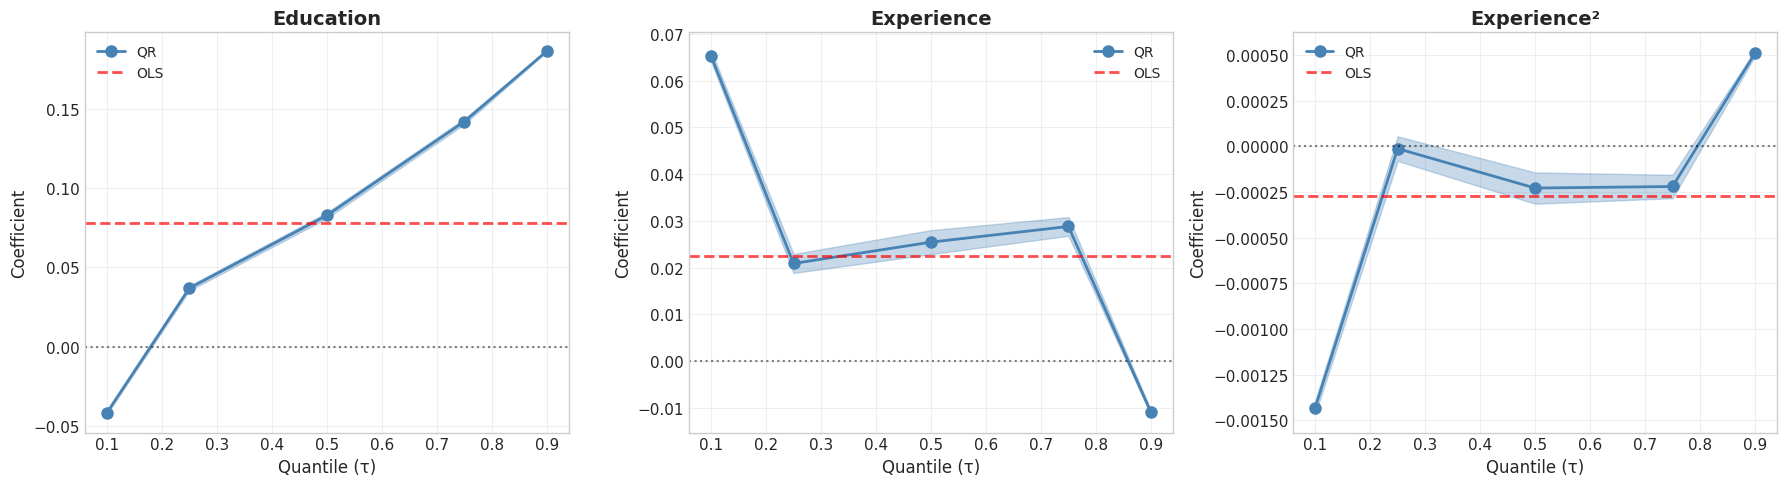

Coefficient path plots saved to outputs/plots/01_coefficient_paths.png


In [13]:
# Coefficient path plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_vars = ["educ", "exper", "exper_sq"]
plot_labels = ["Education", "Experience", "Experience\u00b2"]
ols_param_names = ["educ", "exper", "I(exper ** 2)"]  # OLS formula names

for idx, (var, label, ols_name) in enumerate(zip(plot_vars, plot_labels, ols_param_names)):
    var_idx = var_names.index(var)

    # QR coefficients and confidence intervals
    coefs = [qr_results[tau].params.ravel()[var_idx] for tau in tau_list]
    ses = [qr_results[tau].std_errors.ravel()[var_idx] for tau in tau_list]
    ci_lower = [c - 1.96 * s for c, s in zip(coefs, ses)]
    ci_upper = [c + 1.96 * s for c, s in zip(coefs, ses)]

    # Plot QR coefficients
    axes[idx].plot(tau_list, coefs, "o-", linewidth=2, markersize=8, label="QR", color="steelblue")
    axes[idx].fill_between(tau_list, ci_lower, ci_upper, alpha=0.3, color="steelblue")

    # OLS reference line
    ols_coef = ols_result.params[ols_name]
    axes[idx].axhline(ols_coef, color="red", linestyle="--", linewidth=2, label="OLS", alpha=0.7)

    # Zero reference
    axes[idx].axhline(0, color="black", linestyle=":", alpha=0.5)

    axes[idx].set_xlabel("Quantile (\u03c4)", fontsize=12)
    axes[idx].set_ylabel("Coefficient", fontsize=12)
    axes[idx].set_title(f"{label}", fontsize=14, fontweight="bold")
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_coefficient_paths.png", dpi=300, bbox_inches="tight")
plt.show()

print("Coefficient path plots saved to outputs/plots/01_coefficient_paths.png")

*Figure: Coefficient path plots showing how the effects of education, experience, and experience-squared vary across quantiles (blue line with 95% CI band). The red dashed line shows the OLS estimate for comparison. If the QR line is not flat, the effect is heterogeneous across the distribution.*

### 4.2 Residual Analysis

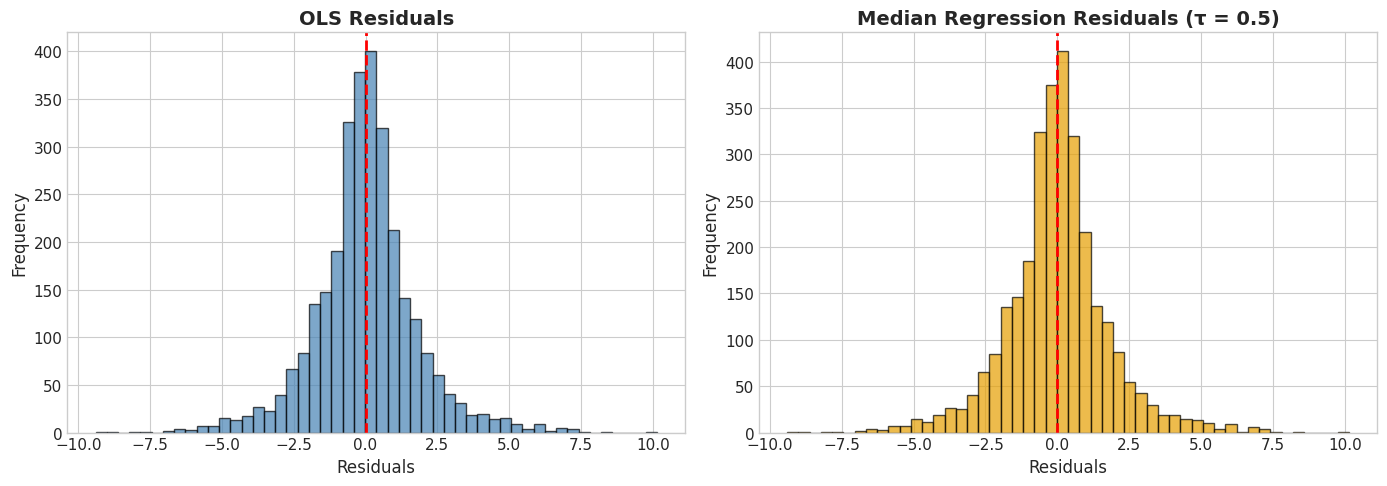


Residual Summary Statistics:


,Statistic,OLS,Median Regression
0,Mean,-2.8303e-15,1.4533e-03
1,Median,-7.4237e-03,-3.1848e-05
2,Std Dev,1.8143e+00,1.8145e+00
3,Skewness,1.2614e-01,1.2652e-01
4,Min,-9.4009e+00,-9.3941e+00
5,Max,1.0151e+01,1.0138e+01


In [14]:
# Compare residuals: OLS vs Median Regression
ols_resid = ols_result.resid
qr50_pred = X @ qr_result_50.params.ravel()
qr50_resid = y - qr50_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OLS residuals
axes[0].hist(ols_resid, bins=50, alpha=0.7, edgecolor="black", color="steelblue")
axes[0].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Residuals", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("OLS Residuals", fontsize=14, fontweight="bold")

# QR (tau=0.5) residuals
axes[1].hist(qr50_resid, bins=50, alpha=0.7, edgecolor="black", color="#E69F00")
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Residuals", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Median Regression Residuals (\u03c4 = 0.5)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_residuals_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary statistics
resid_compare = pd.DataFrame(
    {
        "Statistic": ["Mean", "Median", "Std Dev", "Skewness", "Min", "Max"],
        "OLS": [
            np.mean(ols_resid),
            np.median(ols_resid),
            np.std(ols_resid),
            stats.skew(ols_resid),
            np.min(ols_resid),
            np.max(ols_resid),
        ],
        "Median Regression": [
            np.mean(qr50_resid),
            np.median(qr50_resid),
            np.std(qr50_resid),
            stats.skew(qr50_resid),
            np.min(qr50_resid),
            np.max(qr50_resid),
        ],
    }
)
print("\nResidual Summary Statistics:")
display(resid_compare)

*Figure: Side-by-side histograms of residuals from OLS (left) and median regression (right). Notice the median regression residuals have median closer to zero by construction, while OLS residuals have mean closer to zero.*

---

## 5. Case Study: Wage Inequality and Education

We now conduct a full analysis investigating whether education reduces or amplifies wage inequality.

### Research Questions
1. Do returns to education vary across the wage distribution?
2. Is education a "great equalizer" or does it amplify inequality?
3. How do experience returns differ by wage level?

### 5.1 Fine-Grid Estimation

In [15]:
# Estimate for a fine grid of quantiles
tau_fine = np.arange(0.05, 0.96, 0.05)

qr_results_fine = {}
print(f"Estimating quantile regression for {len(tau_fine)} quantiles...")
for tau in tau_fine:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    qr_results_fine[tau] = model.fit(se_type="cluster")

print("Done.")

# Extract education coefficients
educ_coeffs_fine = [qr_results_fine[tau].params.ravel()[educ_idx] for tau in tau_fine]
educ_se_fine = [qr_results_fine[tau].std_errors.ravel()[educ_idx] for tau in tau_fine]

Estimating quantile regression for 19 quantiles...


Done.


In [16]:
# Test for heterogeneity: is beta(0.9) significantly different from beta(0.1)?
tau_10_key = min(qr_results_fine.keys(), key=lambda t: abs(t - 0.1))
tau_90_key = min(qr_results_fine.keys(), key=lambda t: abs(t - 0.9))

beta_10 = qr_results_fine[tau_10_key].params.ravel()[educ_idx]
beta_90 = qr_results_fine[tau_90_key].params.ravel()[educ_idx]
se_10 = qr_results_fine[tau_10_key].std_errors.ravel()[educ_idx]
se_90 = qr_results_fine[tau_90_key].std_errors.ravel()[educ_idx]

diff = beta_90 - beta_10
se_diff = np.sqrt(se_10**2 + se_90**2)  # Conservative (ignores covariance)
t_stat = diff / se_diff
p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

print("Testing Heterogeneity in Education Returns")
print("=" * 55)
print(f"\u03b2(\u03c4=0.1) = {beta_10:.4f}  (SE: {se_10:.4f})")
print(f"\u03b2(\u03c4=0.9) = {beta_90:.4f}  (SE: {se_90:.4f})")
print(f"Difference = {diff:.4f}")
print(f"t-statistic = {t_stat:.2f}")
print(f"p-value = {p_value:.4f}")
print()
if abs(t_stat) > 1.96:
    print("Result: SIGNIFICANT heterogeneity in education returns across the distribution.")
else:
    print("Result: No significant difference in education returns across the distribution.")

Testing Heterogeneity in Education Returns
β(τ=0.1) = -0.0418  (SE: 0.0005)
β(τ=0.9) = 0.1874  (SE: 0.0002)
Difference = 0.2292
t-statistic = 399.25
p-value = 0.0000

Result: SIGNIFICANT heterogeneity in education returns across the distribution.


### 5.2 Visualization: Education Returns Across the Distribution

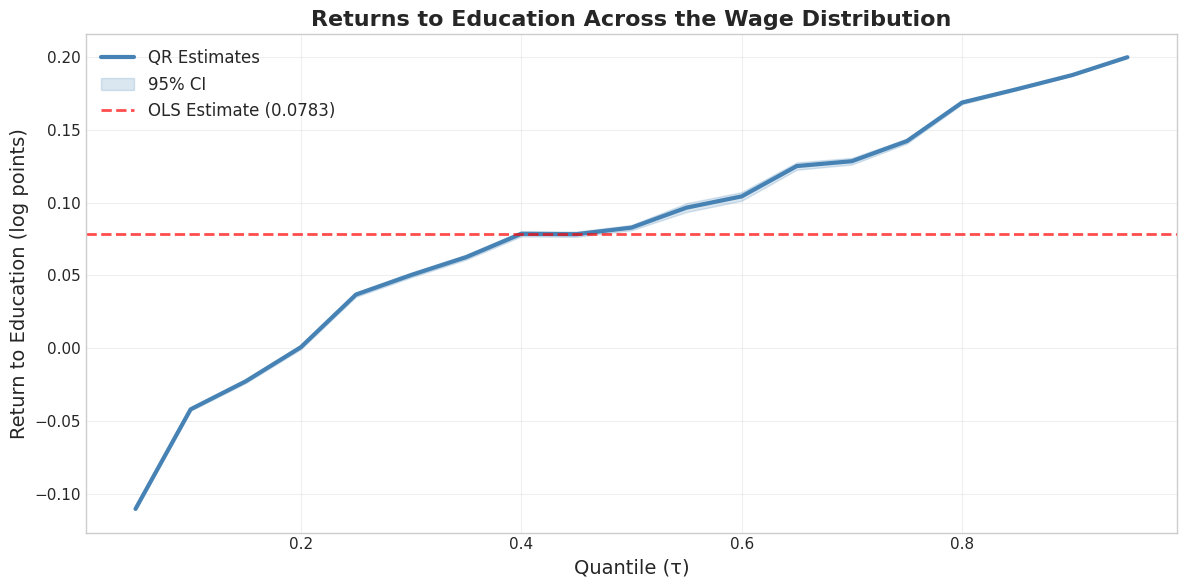

In [17]:
# Plot education returns across the full distribution
fig, ax = plt.subplots(figsize=(12, 6))

# QR estimates with CI band
ci_lower_fine = [c - 1.96 * s for c, s in zip(educ_coeffs_fine, educ_se_fine)]
ci_upper_fine = [c + 1.96 * s for c, s in zip(educ_coeffs_fine, educ_se_fine)]

ax.plot(tau_fine, educ_coeffs_fine, linewidth=3, color="steelblue", label="QR Estimates")
ax.fill_between(
    tau_fine, ci_lower_fine, ci_upper_fine, alpha=0.2, color="steelblue", label="95% CI"
)

# OLS reference
ax.axhline(
    beta_educ_ols,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"OLS Estimate ({beta_educ_ols:.4f})",
    alpha=0.7,
)

ax.set_xlabel("Quantile (\u03c4)", fontsize=14)
ax.set_ylabel("Return to Education (log points)", fontsize=14)
ax.set_title("Returns to Education Across the Wage Distribution", fontsize=16, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_education_returns_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

*Figure: Returns to education across the wage distribution with 95% confidence band. The red dashed line shows the OLS (average) estimate. The upward slope of the QR line indicates that education benefits high-wage workers more than low-wage workers.*

In [18]:
# Save QR results to CSV
results_table = pd.DataFrame(
    {"quantile": list(tau_fine), "educ_coef": educ_coeffs_fine, "educ_se": educ_se_fine}
)

# Add the other variables
for v_idx, vname in enumerate(var_names):
    results_table[f"{vname}_coef"] = [
        qr_results_fine[tau].params.ravel()[v_idx] for tau in tau_fine
    ]
    results_table[f"{vname}_se"] = [
        qr_results_fine[tau].std_errors.ravel()[v_idx] for tau in tau_fine
    ]

results_table.to_csv(RESULTS_DIR / "01_qr_results.csv", index=False)
print(f"Results saved to {RESULTS_DIR / '01_qr_results.csv'}")
print(f"Shape: {results_table.shape}")
display(results_table.head())

Results saved to ../outputs/results/01_qr_results.csv
Shape: (19, 9)


,quantile,educ_coef,educ_se,const_coef,const_se,exper_coef,exper_se,exper_sq_coef,exper_sq_se
0,0.05,-0.1101,0.0004,0.0119,0.0062,0.0409,0.0004,-8.2067e-04,1.3100e-05
1,0.10,-0.0418,0.0005,-0.2099,0.0086,0.0653,0.0006,-1.4315e-03,1.8804e-05
2,0.15,-0.0226,0.0006,0.0111,0.0102,0.0710,0.0007,-1.7428e-03,2.3100e-05
3,0.20,0.0008,0.0007,0.1290,0.0121,0.0666,0.0009,-1.5855e-03,2.7440e-05
4,0.25,0.0369,0.0008,0.3020,0.0135,0.0209,0.0010,-1.2080e-05,3.4421e-05


### 5.3 Interpretation

**Findings:**

1. **Heterogeneity**: Returns to education vary substantially across the wage distribution. Workers at the top of the distribution benefit more from education than workers at the bottom.

2. **Inequality Amplification**: Education appears to amplify wage inequality rather than reducing it. The gap between high and low quantile returns suggests that education widens the wage distribution.

3. **Policy Implications**:
   - Education alone may not reduce inequality — additional interventions targeting low-wage workers are needed.
   - The OLS estimate averages over this heterogeneity and would lead to incomplete policy conclusions.

4. **OLS Limitation**: The OLS estimate hides the distributional pattern. Relying solely on OLS would miss that education disproportionately benefits high earners.

---

## 6. When to Use QR vs OLS

### Decision Guide

| Question | If YES | If NO |
|----------|--------|-------|
| Interested **only** in average effects? | Use OLS (simpler, more efficient) | Consider QR |
| Interested in distributional effects? | Use QR | Use OLS |
| Worried about outliers? | QR (especially \u03c4=0.5) is robust | OLS is fine |
| Heteroskedasticity present? | QR can reveal heterogeneous effects | OLS with robust SE |
| Policy targets specific groups? | Use QR to identify winners/losers | OLS sufficient |
| Risk/tail behavior matters? | QR for tail quantiles | OLS for average |

### When to Use Quantile Regression

- You want to understand effects across the distribution
- Heterogeneous treatment effects are of interest
- Outliers are present (median regression is robust)
- Policy targets specific groups (e.g., low earners)
- Risk/tail behavior is important (finance, insurance)

### When NOT to Use Quantile Regression

- Only average effects matter
- Sample size is very small (< 100 observations)
- Interpretation complexity outweighs benefits
- Standard errors are primary concern (OLS is more efficient at the mean under normality)

---

## Summary and Key Takeaways

1. **Conditional Quantiles vs Conditional Mean**: OLS estimates $E(Y|X)$; QR estimates $Q_\tau(Y|X)$ for any $\tau \in (0,1)$. Each quantile has its own set of coefficients.

2. **Check Loss Function**: QR minimizes the asymmetric check loss $\rho_\tau(u) = u(\tau - \mathbf{1}\{u<0\})$. The asymmetry controls which quantile is estimated.

3. **Heterogeneity**: When QR coefficients vary across quantiles, it reveals heterogeneous effects hidden by OLS. In our wage analysis, education returns increased with quantile level.

4. **Robustness**: Median regression ($\tau=0.5$) is more robust to outliers than OLS.

5. **Pseudo-R\u00b2**: Measures goodness-of-fit within the QR framework but is not comparable to OLS R\u00b2.

### References

1. Koenker, R., & Bassett, G. (1978). Regression Quantiles. *Econometrica*, 46(1), 33–50.
2. Koenker, R. (2005). *Quantile Regression*. Cambridge University Press.
3. Buchinsky, M. (1998). Recent Advances in Quantile Regression Models. *Journal of Human Resources*, 33(1), 88–126.
4. Hao, L., & Naiman, D.Q. (2007). *Quantile Regression*. Sage Publications.

### Next Steps

In **Notebook 02**, we will explore **Fixed Effects Quantile Regression**, which controls for unobserved individual heterogeneity in panel data.

---

## Exercises

### Exercise 1: Conceptual Understanding (Easy)

**Question**: Why is the check loss function asymmetric? What would happen if we used symmetric loss (e.g., squared loss) for quantile estimation?

**Hint**: Think about what quantile means — it's not the center of the data. What must the loss function do to pull the estimator toward a specific quantile?

In [19]:
# Exercise 1: Write your answer as comments or markdown.
# You can also verify numerically: show that symmetric loss always gives the mean/median
# while asymmetric loss gives other quantiles.

# Your answer here:


### Exercise 2: Implementation (Easy)

**Task**:
1. Using the card_education data, estimate QR for \u03c4 = {0.1, 0.3, 0.5, 0.7, 0.9}
2. Create a coefficient path plot for the `exper` variable
3. Interpret the results: does the return to experience vary across quantiles?

In [20]:
# Exercise 2: Coefficient path for experience
tau_list_ex2 = [0.1, 0.3, 0.5, 0.7, 0.9]
results_ex2 = {}

# TODO: Estimate QR for each tau
# TODO: Extract 'exper' coefficients and standard errors
# TODO: Create coefficient path plot with CI band and OLS reference line

### Exercise 3: Interpretation (Medium)

**Given** the following QR results for a wage regression with a `college_degree` variable:

| Quantile | Coefficient | Std. Error |
|----------|------------|------------|
| \u03c4 = 0.1 | 0.15 | 0.03 |
| \u03c4 = 0.5 | 0.25 | 0.02 |
| \u03c4 = 0.9 | 0.40 | 0.05 |
| OLS | 0.25 | 0.02 |

**Questions**:

a) Interpret each coefficient in plain language.  
b) What does this pattern suggest about college education and wage inequality?  
c) Why might the OLS coefficient be misleading?

In [21]:
# Exercise 3: Write your interpretation

# a) Interpretation of each coefficient:

# b) Pattern and wage inequality:

# c) Why OLS is misleading:


### Exercise 4: Robustness to Outliers (Medium)

**Task**: Demonstrate that median regression is more robust to outliers than OLS.

**Steps**:
1. Generate clean data: $y = 2 + 3x + \varepsilon$, where $\varepsilon \sim N(0,1)$
2. Add extreme outliers to 5% of observations (e.g., multiply y by 10)
3. Compare OLS and QR ($\tau=0.5$) slope coefficients on clean vs contaminated data
4. Visualize the difference

In [22]:
# Exercise 4: Robustness comparison
np.random.seed(123)
n = 500

# Generate clean data
X_ex4 = np.random.normal(0, 1, n)
y_clean = 2 + 3 * X_ex4 + np.random.normal(0, 1, n)

# TODO: Add outliers to 5% of observations

# TODO: Fit OLS and QR (tau=0.5) on both clean and contaminated data

# TODO: Compare and visualize

### Exercise 5: Verify Median Minimizes Absolute Deviations (Hard)

**Task**: Prove numerically that minimizing the check loss with $\tau=0.5$ gives the sample median.

**Hint**: Generate a sample, then show that the check loss $\sum_i \rho_{0.5}(y_i - c)$ is minimized at $c = \text{median}(y)$ by evaluating the loss over a grid of candidate values.

In [23]:
# Exercise 5: Verify median minimizes absolute deviations
np.random.seed(42)

# TODO: Generate a skewed sample
# TODO: Evaluate check loss at tau=0.5 over a grid of candidate values
# TODO: Show that the minimum occurs at the sample median
# TODO: Repeat for tau=0.25 and tau=0.75

### Exercise 6: Real-World Application (Hard)

**Scenario**: You are analyzing house prices. You have data on:
- `log_price`: Log of house sale price
- `sqft`: Square footage
- `beds`: Number of bedrooms
- `dist_center`: Distance to city center (km)

**Questions**:

1. Why might QR be more appropriate than OLS for this problem?  
2. What would you expect for the coefficient of `dist_center` at different quantiles?  
3. How would you present QR results to a non-technical real estate client?

In [24]:
# Exercise 6: Write your analysis

# 1. Why QR for house prices?

# 2. Expected pattern for dist_center:

# 3. How to present to non-technical audience:
